## <span style='text-decoration: double underline;color:rgb(10,110,217)'>**Results Classic Model**</span>

**Loss function configuration:**

$\lambda_{init} = 1$  
$\lambda_{phys} = 0$  
$\lambda_{bin} = 0$

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('../')

In [3]:
import utils.evaluation_tools as eval_tools

delta = 1 
shape = (25,25)
model_name = 'Classic'
parent_folder = '../Data'
seed2plot = 221
seeds = [221, 502, 700, 1204, 3340, 4501, 6054, 6621,8421, 15678, 19302, 38475, 77293, 91827, 99100]  

figsize = (12,9)
subplots_grid = (3,3)
suptitle = 'Classic Model'
threshold = 0.5

th_ranges = [(0.45, 0.55), (0.40, 0.60), (0.35, 0.65)]

train_history_paths = eval_tools.get_paths_results('train_history.csv', parent_folder, seeds, shape, delta, model_name)
predictions_paths = eval_tools.get_paths_results('predictions.csv', parent_folder, seeds, shape, delta, model_name)
test_results_paths = eval_tools.get_paths_results('test_results.csv', parent_folder, seeds, shape, delta, model_name)
test_data = eval_tools.get_paths_results('test.npz', parent_folder, seeds, shape, delta, model_name) 

### <span style='color:rgb(10,110,217)'><u>**Train Results**</u></span>

--- Metrics computed during execution ---
loss: 0.0676 ± 0.0001
val_loss: 0.0686 ± 0.0003


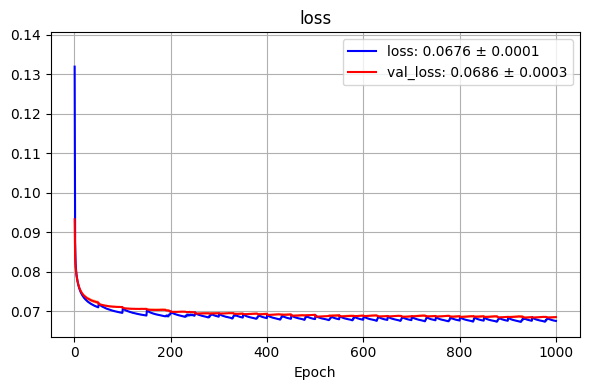

In [4]:
cols2omit = 1
num_rows = 1
eval_tools.display_results(train_history_paths, 'val_', cols2omit, num_rows, True, True)

### <span style='color:rgb(10,110,217)'><u>**Test Results**</u></span>

In [5]:
# Test:
eval_tools.display_results(test_results_paths, '_fin', display_plot=False)

--- Metrics computed during execution ---
Accuracy_init: 0.8815 ± 0.0003
Accuracy_fin: 0.8010 ± 0.0002
Recall_init: 0.6390 ± 0.0035
Recall_fin: 0.0038 ± 0.0003
Specificity_init: 0.9448 ± 0.0008
Specificity_fin: 0.9995 ± 0.0000
Precision_init: 0.7515 ± 0.0018
Precision_fin: 0.6462 ± 0.0166
F1Score_init: 0.6907 ± 0.0013
F1Score_fin: 0.0076 ± 0.0006


--- Results Initial States (15 seeds) ---
Density (true): 20.71% ± 8.76%
Density (pred): 30.29% ± 8.08%
Error/seed:     9.59% ± 0.12%
Max value predicted: 0.9949
HUC% (0.45, 0.55): 9.97% ± 0.09%
HUC% (0.4, 0.6): 19.60% ± 0.16%
HUC% (0.35, 0.65): 29.09% ± 0.21%
Fuzziness Index: 0.7041 ± 0.1435
MSE (prob):0.2085 ± 0.0399
MSE (bin):0.3102 ± 0.0721
MSE (all-zero): 0.2071 ± 0.0876
Wasserstein (EMD): 3.4431 ± 0.0107


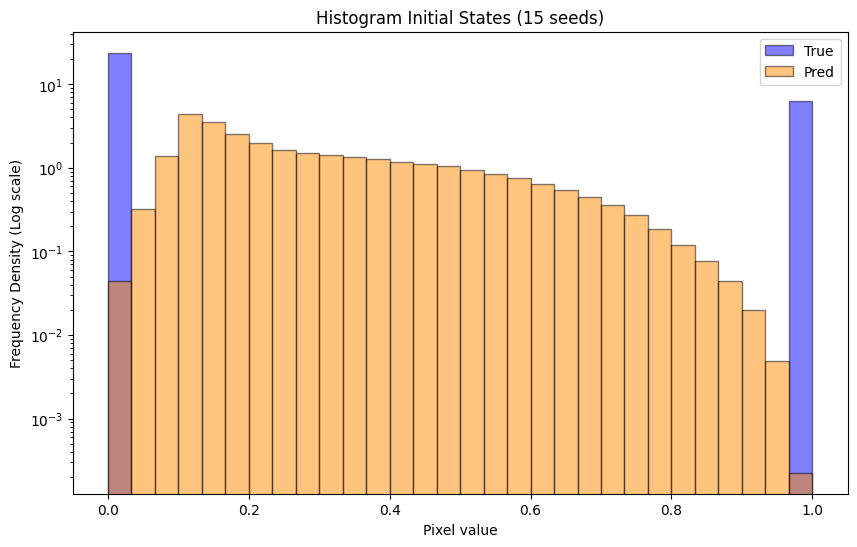

In [6]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'init', th_ranges, threshold, colors=['blue', 'darkorange'])

--- Results Final States (15 seeds) ---
Density (true): 19.93% ± 8.62%
Density (pred): 2.10% ± 0.72%
Error/seed:     17.83% ± 0.07%
Max value predicted: 0.9935
HUC% (0.45, 0.55): 0.14% ± 0.01%
HUC% (0.4, 0.6): 0.31% ± 0.01%
HUC% (0.35, 0.65): 0.57% ± 0.02%
Fuzziness Index: 0.0672 ± 0.0245
MSE (prob):0.1952 ± 0.0826
MSE (bin):0.2001 ± 0.0860
MSE (all-zero): 0.1993 ± 0.0862
Wasserstein (EMD): 4.9060 ± 0.0206


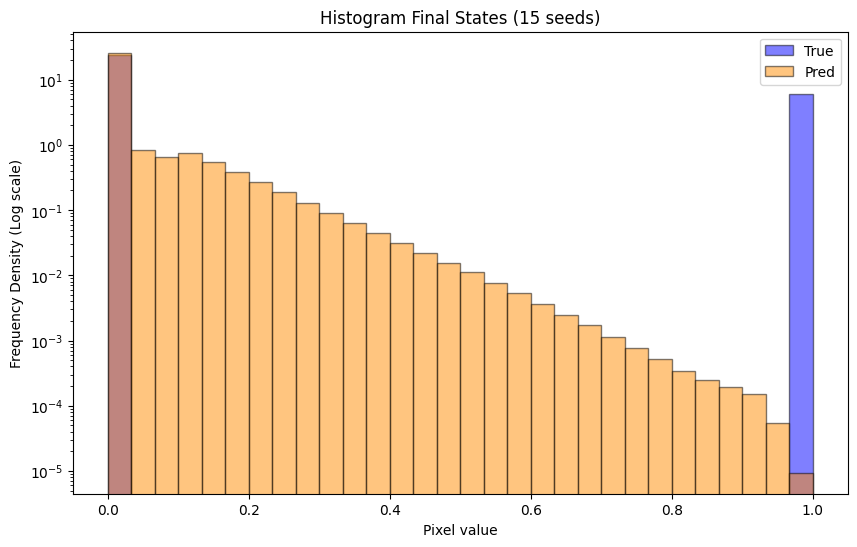

In [7]:
eval_tools.compute_metrics(predictions_paths, test_data,shape,'fin', th_ranges, threshold, colors=['blue', 'darkorange'])

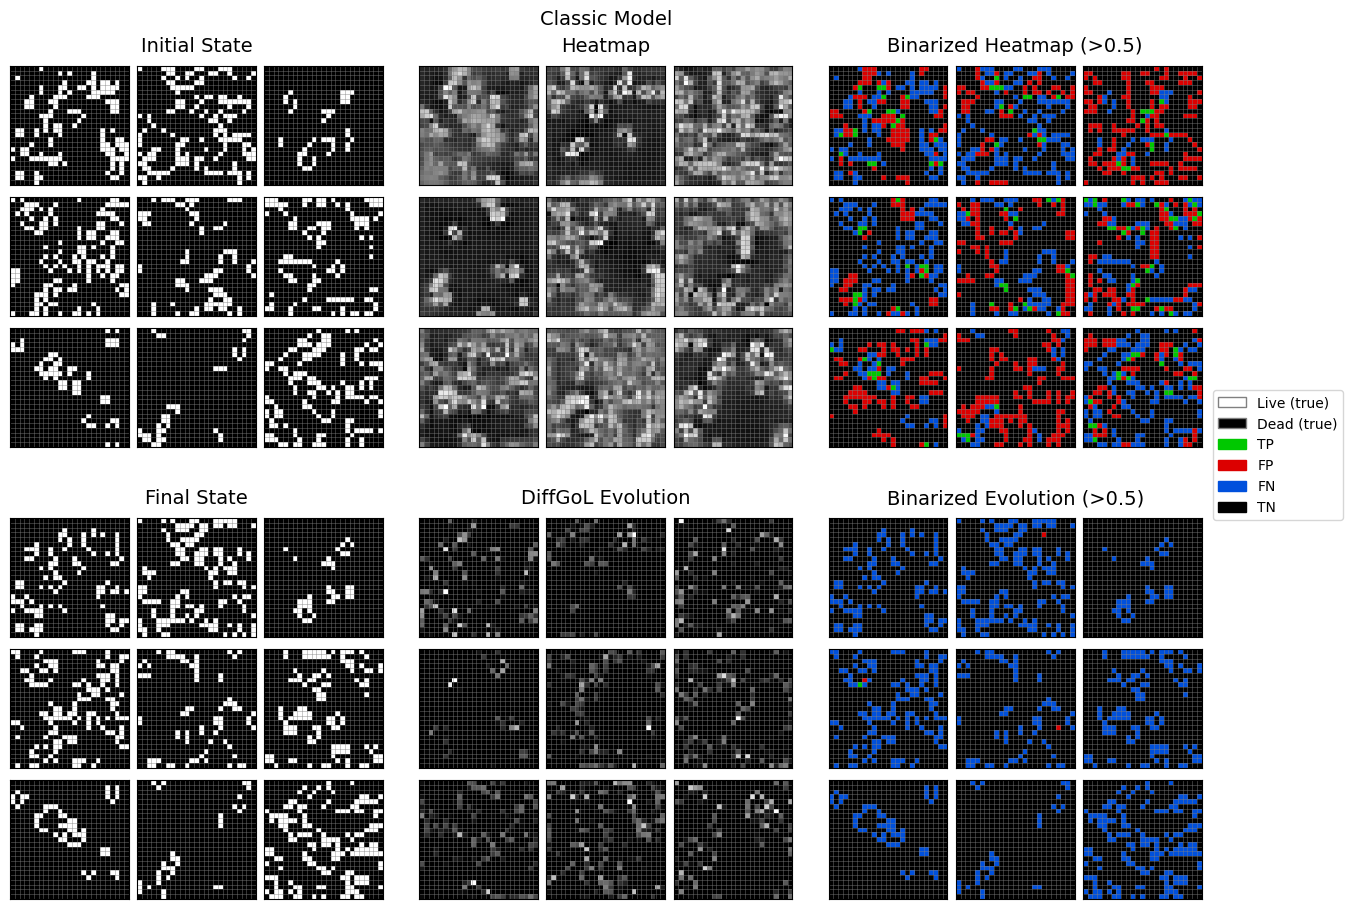

In [8]:
file_test = test_data[seed2plot]
file_pred = predictions_paths[seed2plot]
titles = ['Initial State', 'Heatmap', f'Binarized Heatmap (>{threshold})', 
          'Final State', 'DiffGoL Evolution', f'Binarized Evolution (>{threshold})']
eval_tools.display_states(file_pred, file_test, shape, threshold, titles, subplots_grid, suptitle, figsize, random=False)